# Nonlinear Least Squares Benchmark Analysis ($n<m$ case)

In [1]:
from experiments import *
from visualization import *

import inspect
import optimization_project.problems.overdetermined as overdetermined_problems_module

In [2]:
problems = [
    cls() for name, cls in inspect.getmembers(overdetermined_problems_module, inspect.isclass)
    if name.endswith("Problem") and name != "Problem"
]

## Overall Results

In [3]:
df_results = benchmark_methods(problems)

 ---- Running problem: Bennett5
 ---- Running problem: BoxBOD
 ---- Running problem: Chwirut1


c:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\.venv\Lib\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))


 ---- Running problem: DanWood
 ---- Running problem: Eckerle4
 ---- Running problem: Kirby2
 ---- Running problem: Lanczos3
 ---- Running problem: MGH17


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]


 ---- Running problem: Misra1a
 ---- Running problem: Misra1c
 ---- Running problem: Rat42
 ---- Running problem: Roszman1
 ---- Running problem: Thurber


In [4]:
df_results

,problem,difficulty,classification_model,structure,method,start_name,success,iterations,final_rss,parameter_error,relative_parameter_error,rss_error,relative_rss_error,gradient_norm
0,Bennett5,Higher,Miscellaneous,Overdetermined,ModifiedGN,NIST Start 1,False,100,5.338949e-04,4.379531e+02,1.735197e-01,9.847433e-06,1.879111e-02,1.832351e-01
1,Bennett5,Higher,Miscellaneous,Overdetermined,LM-lm,NIST Start 1,False,100,7.023387e-04,1.292884e+03,5.122487e-01,1.782912e-04,3.402196e-01,1.107290e+00
2,Bennett5,Higher,Miscellaneous,Overdetermined,ModifiedGN,NIST Start 2,False,100,5.896484e-04,9.359081e+02,3.708125e-01,6.560101e-05,1.251814e-01,1.174430e-01
3,Bennett5,Higher,Miscellaneous,Overdetermined,LM-lm,NIST Start 2,False,100,5.244792e-04,1.010744e+02,4.004631e-02,4.317608e-07,8.238963e-04,1.550052e-01
4,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,26,1.168009e+03,1.762844e-07,8.244907e-10,4.444701e-08,3.805365e-11,1.199891e-04
5,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 1,True,10,9.771500e+03,9.662656e+01,4.519270e-01,8.603491e+03,7.365947e+00,7.341368e-35
6,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 2,True,12,1.168009e+03,1.230070e-07,5.753095e-10,4.444723e-08,3.805385e-11,1.417062e-05
7,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 2,True,8,1.168009e+03,1.660473e-03,7.766111e-06,7.757208e-06,6.641395e-09,4.053286e-01
8,Chwirut1,Lower,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,20,2.384477e+03,5.258503e-09,2.757937e-08,9.350970e-09,3.921602e-12,4.910091e-03
9,Chwirut1,Lower,Exponential,Overdetermined,LM-lm,NIST Start 1,True,9,2.384477e+03,6.537914e-06,3.428952e-05,1.145087e-06,4.802258e-10,4.790192e+00


---

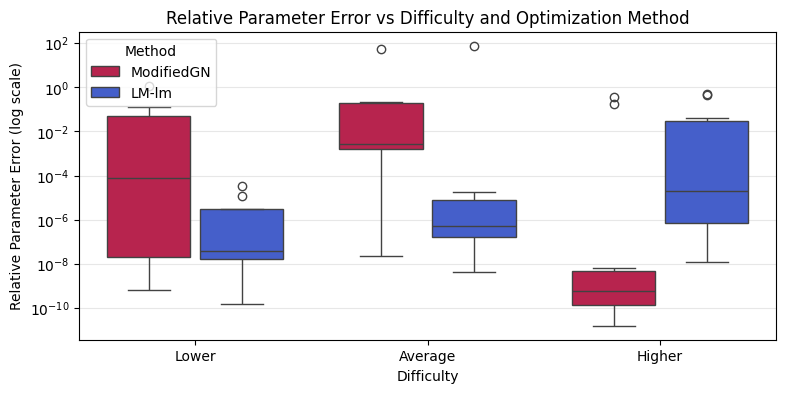

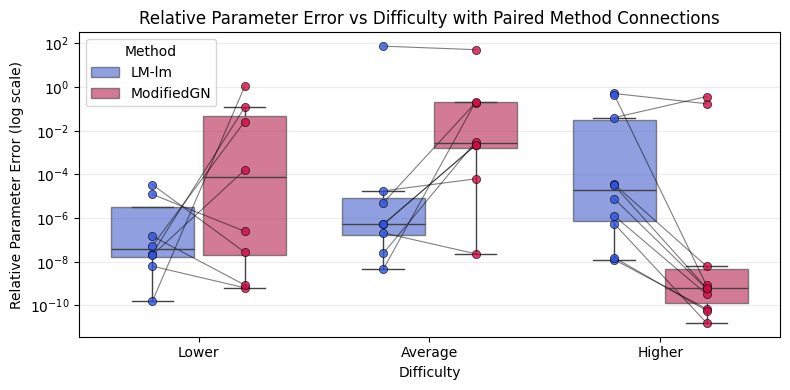

In [5]:
plot_boxplot(df_results, x="difficulty", y="relative_parameter_error",
             xlabel="Difficulty", ylabel="Relative Parameter Error",
             order=difficulty_order, palette=method_palette)

plot_boxplot_with_connections(df_results, x="difficulty", y="relative_parameter_error",
             xlabel="Difficulty", ylabel="Relative Parameter Error",
             order=difficulty_order, palette=method_palette)

In [6]:
problems_2d = [p for p in problems if p.n == 2]

c:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\.venv\Lib\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_higher.py:187: RuntimeWarning: overflow encountered in multiply
  return b[0] * (1 - np.exp(-b[1] * x))
c:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\notebooks\visualization.py:312: RuntimeWarning: overflow encountered in square
  Z[i, j] = np.sum(problem.F(p)**2)


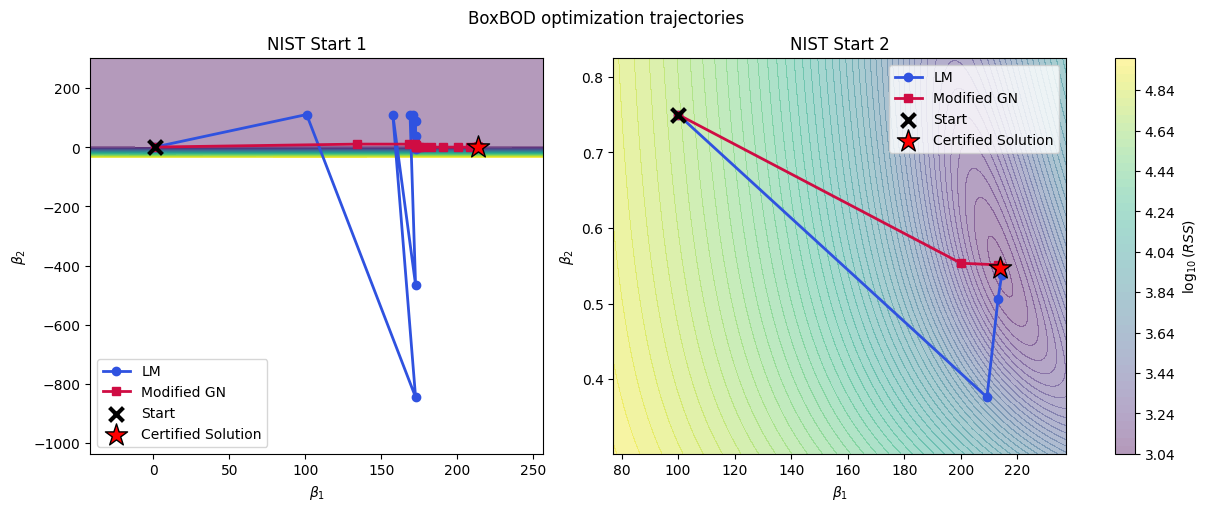

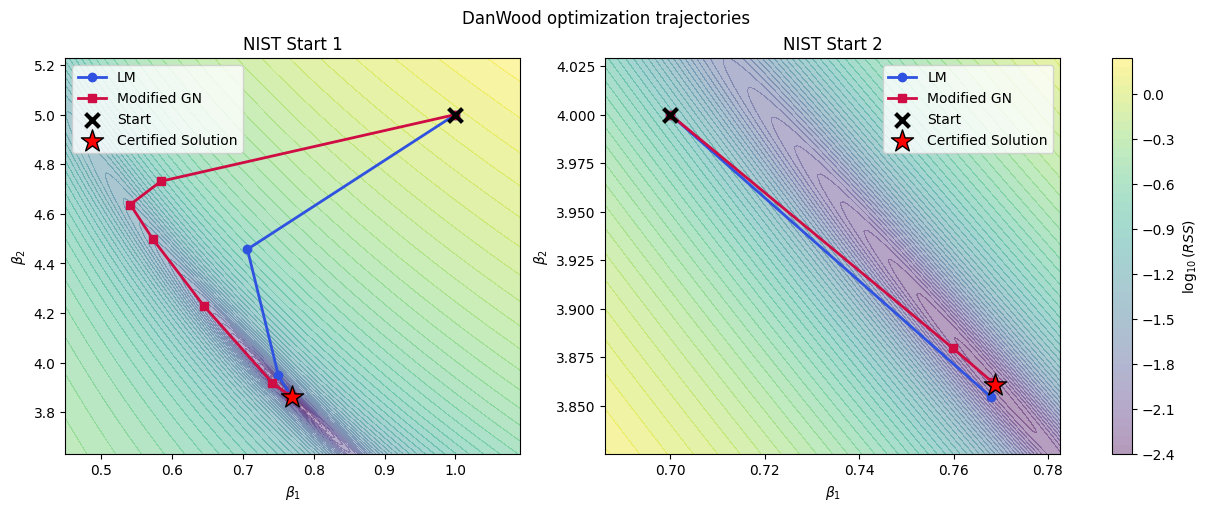

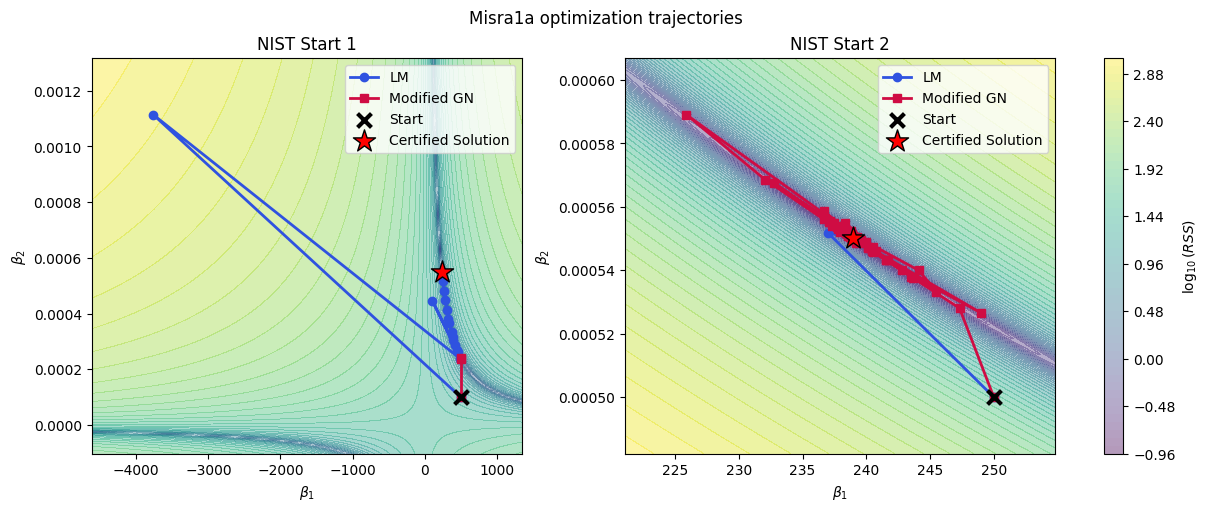

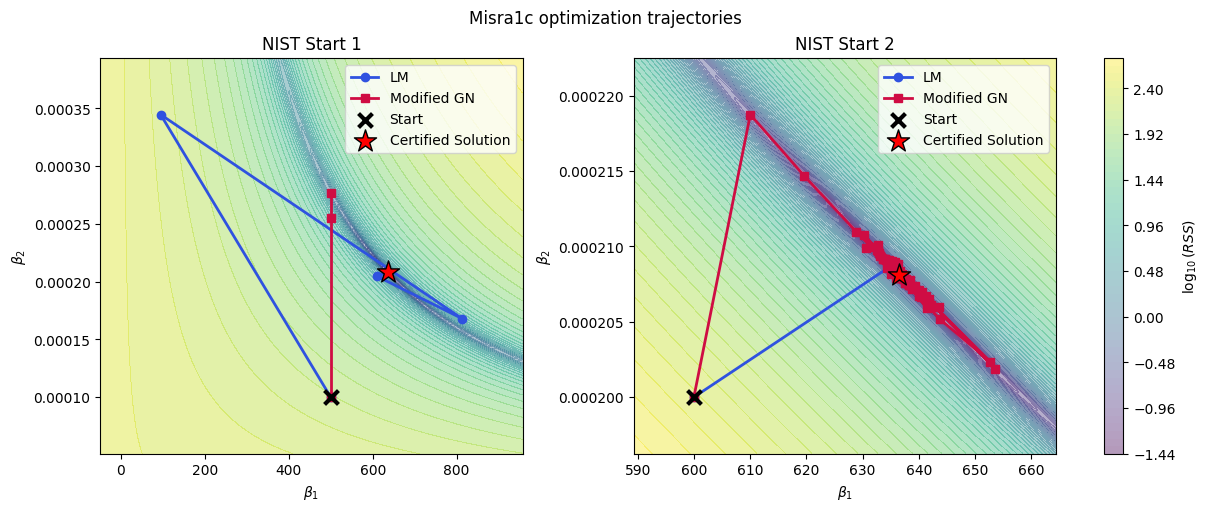

In [7]:
trajectory_data = generate_trajectory_data(
    problems_2d
)

for problem_data in trajectory_data:

    plot_optimizer_paths(problem_data)

---

In [8]:
def compare_methods_convergence(problems):

    for problem in problems:

        starts = problem.get_starting_points()
        n_starts = len(starts)

        print(f"\n=== {problem.name} ===")

        fig, axes = plt.subplots(1, n_starts, figsize=(6 * n_starts, 5), constrained_layout=True)

        if n_starts == 1:
            axes = [axes]

        for ax, (name, x0) in zip(axes, starts.items()):

            # ---------------------------------------------------
            # 1. Modified GN (Secular)
            # ---------------------------------------------------

            result_mgn = modified_gauss_newton(problem,
                x0,
                M0=1e-3,
                L0=1e-6,
                tol=1e-6,
                max_iter=100,
                subproblem_method="secular"
            )

            # ---------------------------------------------------
            # 2. SciPy LM (history safe extraction)
            # ---------------------------------------------------

            lm_res = run_lm_with_history(problem, x0)
            hist_sp = [
                np.sum(problem.F(x) ** 2)
                for x in lm_res.x_history
            ]


            ax.semilogy(result_mgn.rss_history, label="Modified GN", linewidth=2,
                        color=method_palette["ModifiedGN"])

            ax.semilogy(hist_sp, label="SciPy LM", linewidth=2, 
                        color=method_palette["LM-lm"], alpha=0.9)

            ax.set_title(name)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("RSS")
            ax.grid(True, which="both", ls="-", alpha=0.4)
            ax.legend()

        fig.suptitle(
            f"{problem.name} – convergence comparison",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()


=== Bennett5 ===


C:\Users\olenk\AppData\Local\Temp\ipykernel_79432\210592795.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


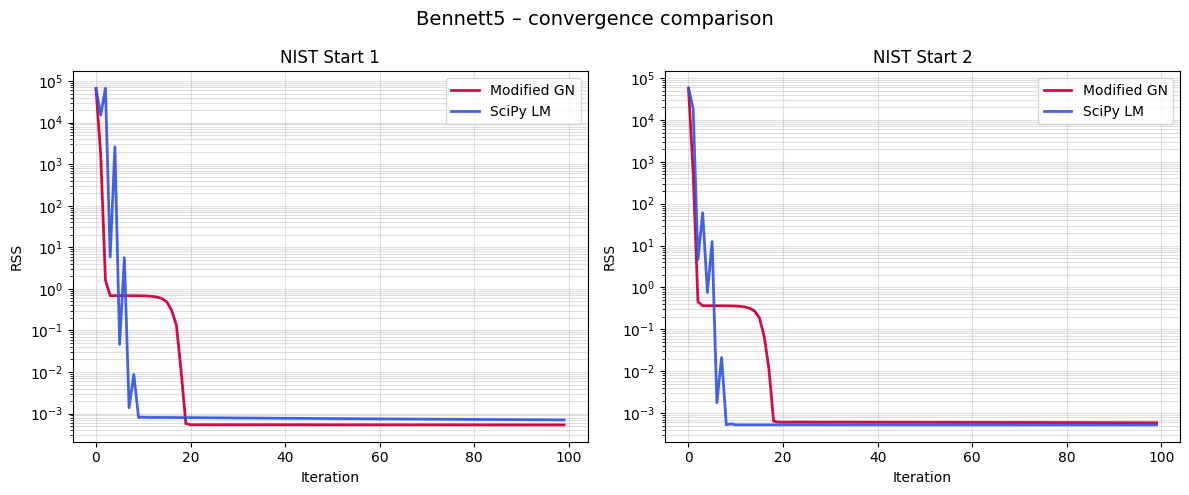


=== BoxBOD ===


C:\Users\olenk\AppData\Local\Temp\ipykernel_79432\210592795.py:36: RuntimeWarning: overflow encountered in square
  np.sum(problem.F(x) ** 2)


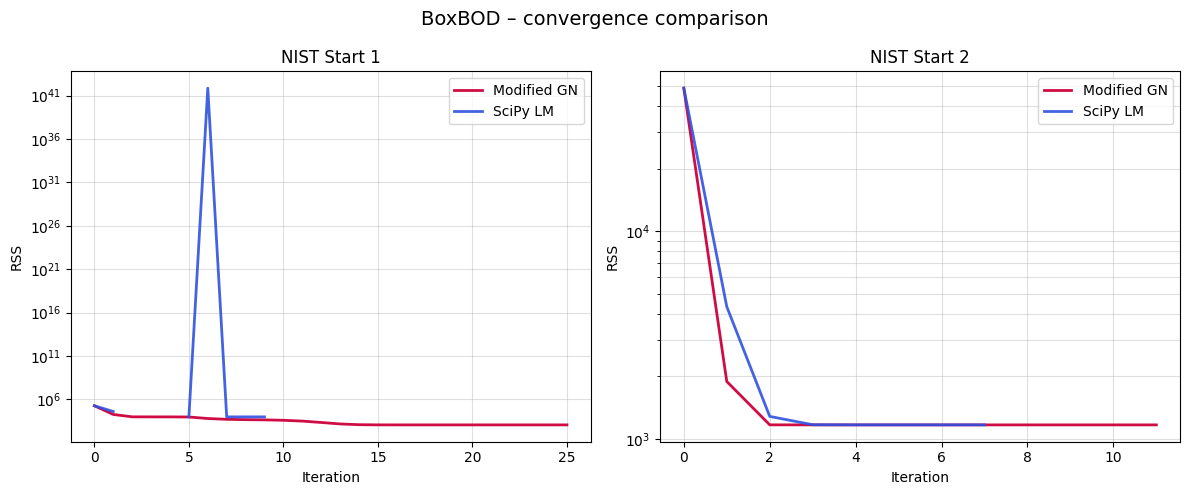


=== Chwirut1 ===


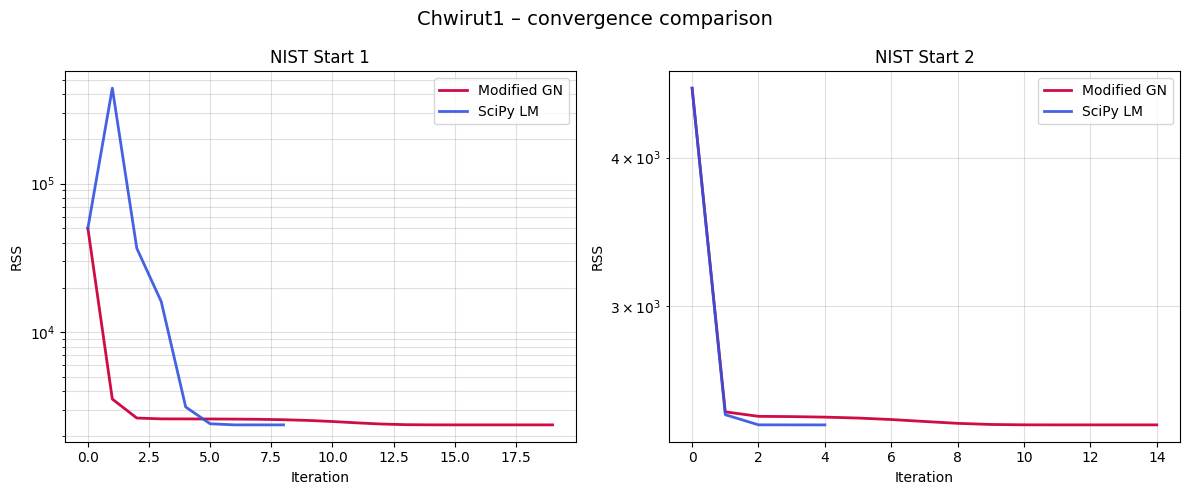


=== DanWood ===


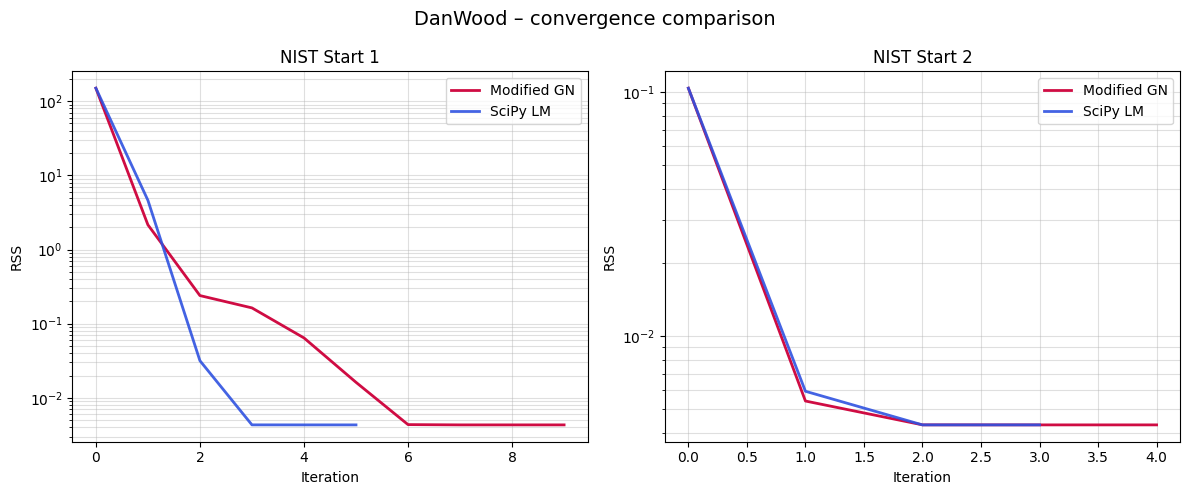


=== Eckerle4 ===


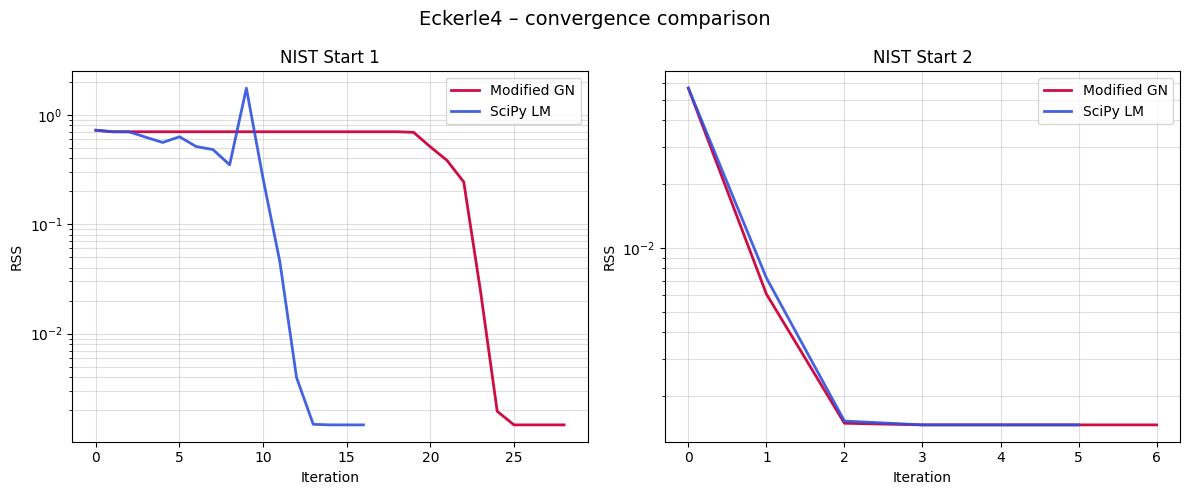


=== Kirby2 ===


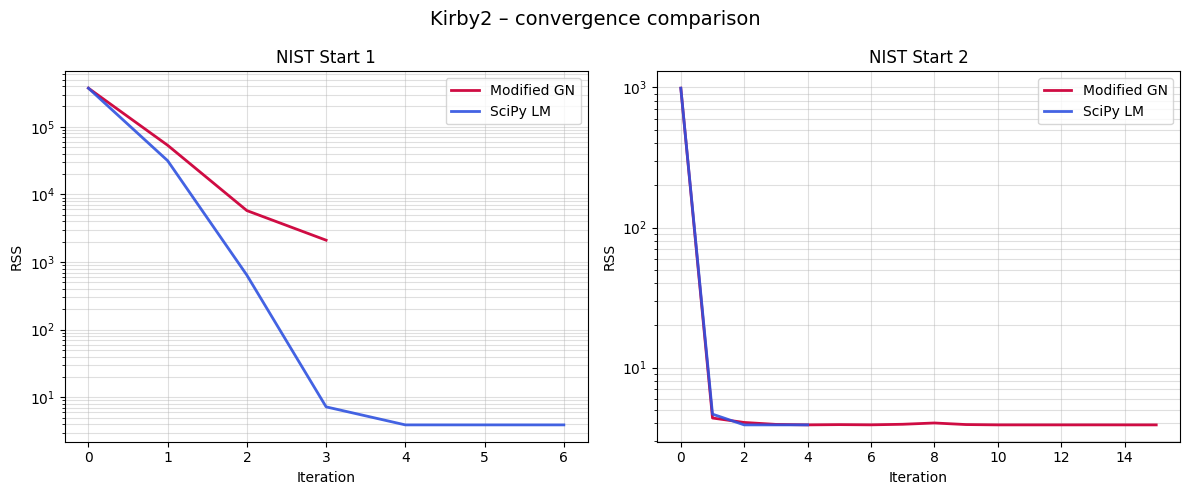


=== Lanczos3 ===


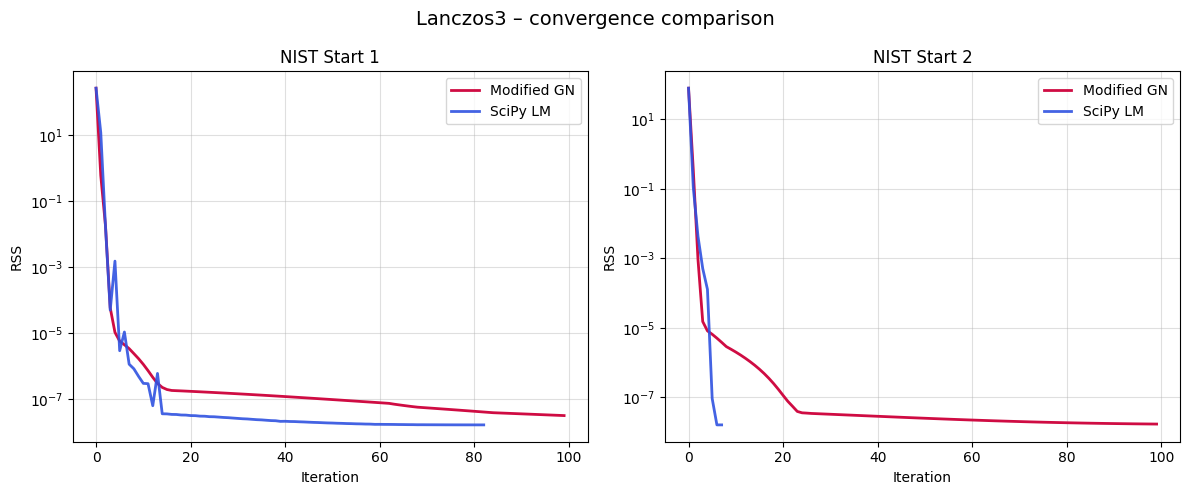


=== MGH17 ===


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\overdetermined\problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]


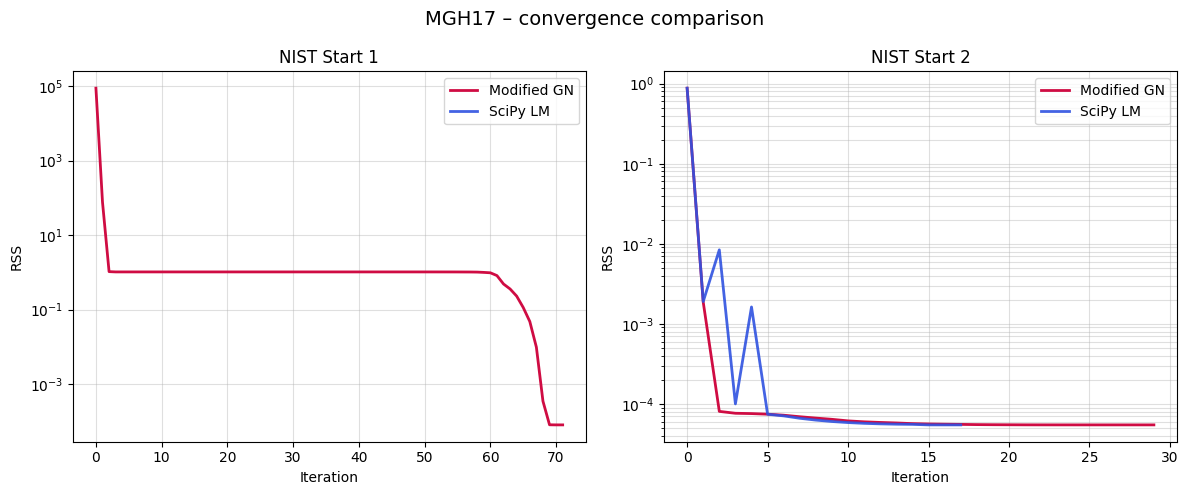


=== Misra1a ===


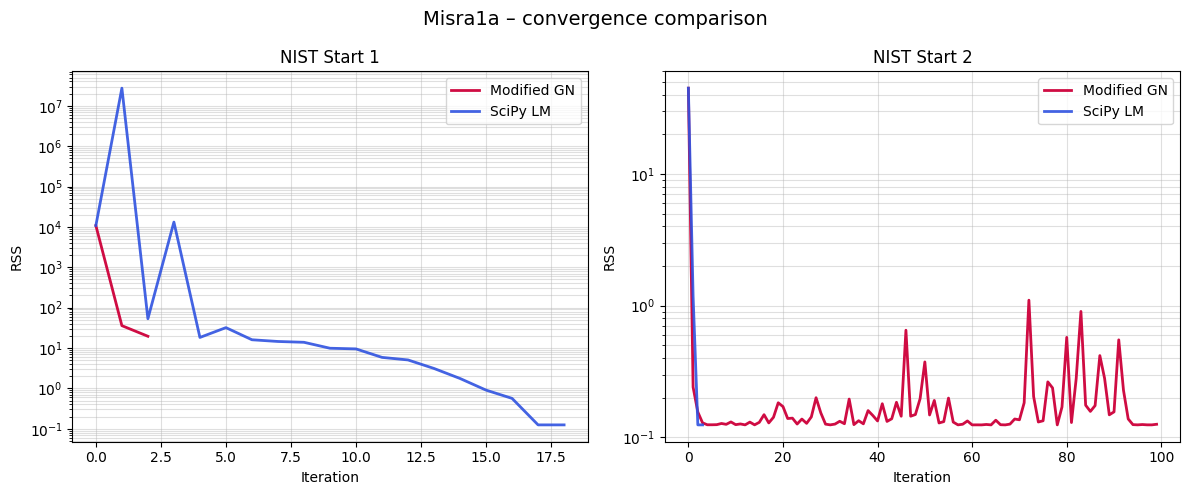


=== Misra1c ===


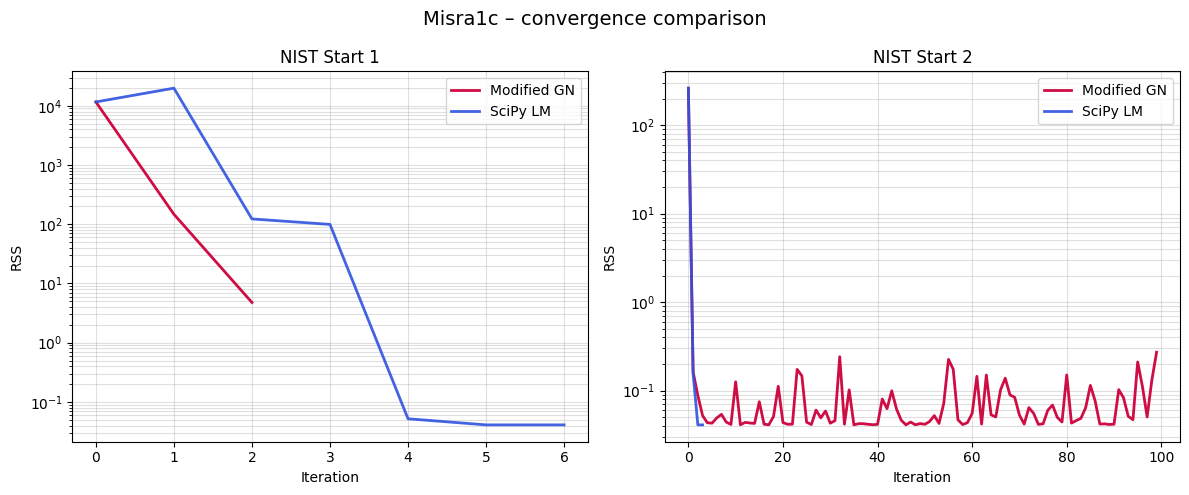


=== Rat42 ===


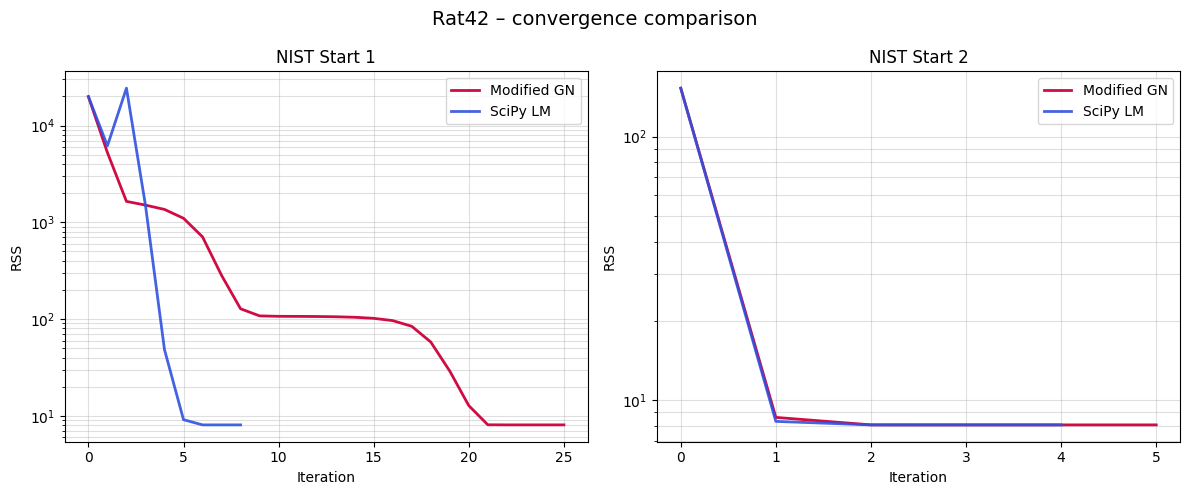


=== Roszman1 ===


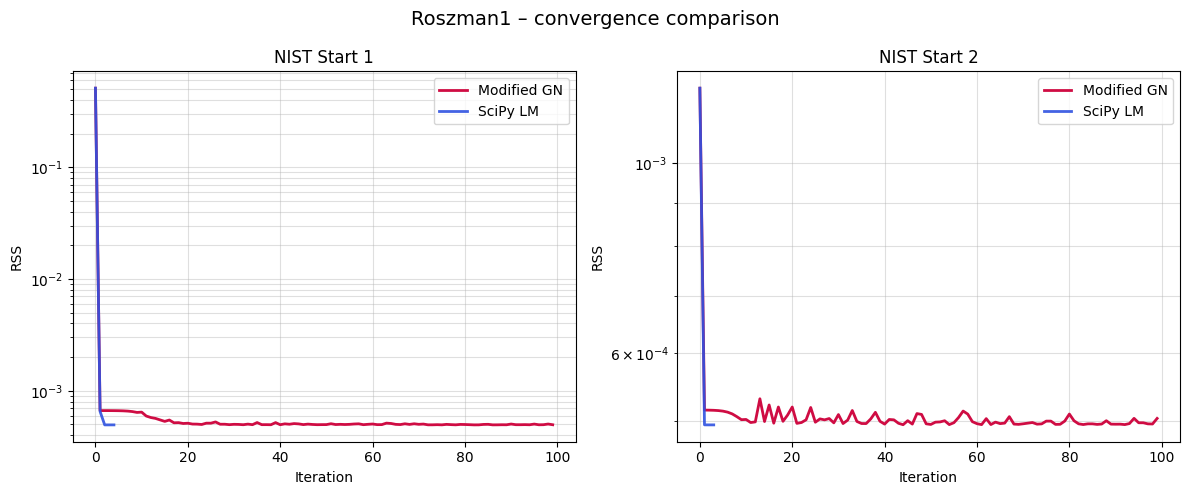


=== Thurber ===


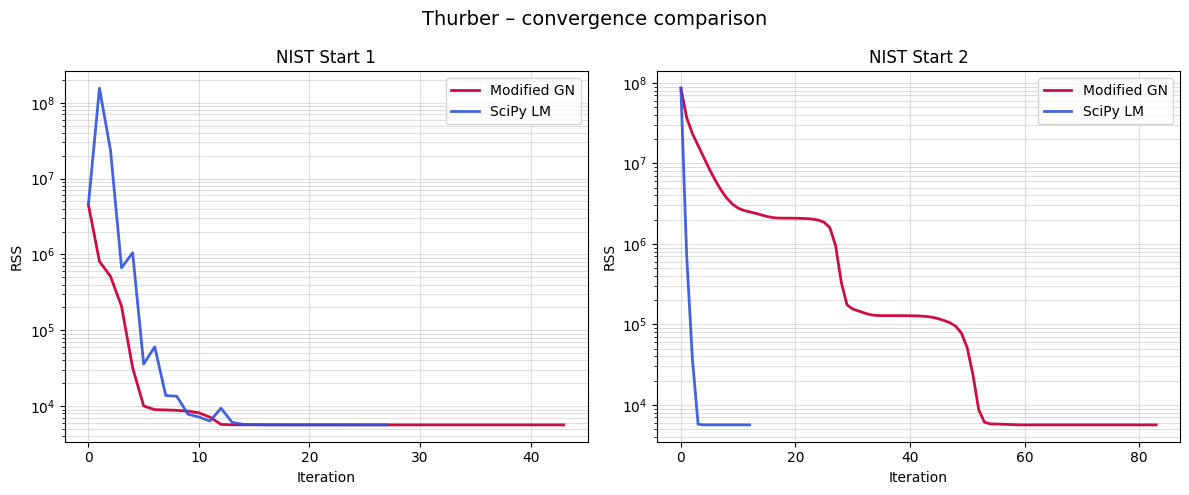

In [9]:
compare_methods_convergence(problems)